# Global 6-Panel Intensity Relationship: IKE vs. Vmax / Pmin

Six-panel scatter (one panel per basin) of total IKE against an intensity metric
(Vmax or Pmin), color-coded by R34 wind-field size, with a linear fit and an
annotated window around a target intensity value per panel.

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [2]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"

## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from ike_climatology import config
from ike_climatology.ibtracs_io import load_master_dataframe


## Data extraction

Uses `load_master_dataframe`'s defaults (`apply_quality_filters=True`).

In [4]:
master_df = load_master_dataframe(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")

valid_ike_master = master_df.dropna(subset=["total_ike_tj"]).copy()
valid_ike_master = valid_ike_master[valid_ike_master["total_ike_tj"] > 0]

print(f"{len(valid_ike_master)} valid timesteps across "
      f"{valid_ike_master['storm_id'].nunique()} storms.")


--- Starting Initial Data Loading and Processing for All Basins ---
    - Loading IBTrACS data for North Atlantic (2004-2024)
        Found 380 storms in file.
        - Filtered out 2 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for East Pacific (2004-2024)
        Found 497 storms in file.
        - Filtered out 79 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for West Pacific (2004-2024)
        Found 622 storms in file.
        - Filtered out 16 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for North Indian (2004-2024)
        Found 220 storms in file.
        - Filtered out 13 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for South Indian (2004-2024)
        Found 367 storms in file.
        - Filtered out 22 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data

## Figure config

Set `INTENSITY_METRIC` to `"vmax"` or `"pmin"`.

In [5]:
INTENSITY_METRIC = "pmin"  # or "vmax"

INTENSITY_CONFIGS = {
    "vmax": dict(
        x_col="vmax_kts", x_label="Maximum Wind (kts)", title_var="Vmax",
        target=80, tol=0, unit_label="kts",
        xlim=(20, 175), invert_xaxis=False,
        filename="global_6panel_ike_vmax_quadratic.png",
    ),
    "pmin": dict(
        x_col="pmin_mb", x_label="Minimum Pressure (mb)", title_var="Pmin",
        target=960, tol=1, unit_label="mb",
        xlim=(865, 1020), invert_xaxis=True,
        filename="global_6panel_ike_pmin_quadratic.png",
    ),
}


## Figure: 6-panel IKE vs. intensity scatter

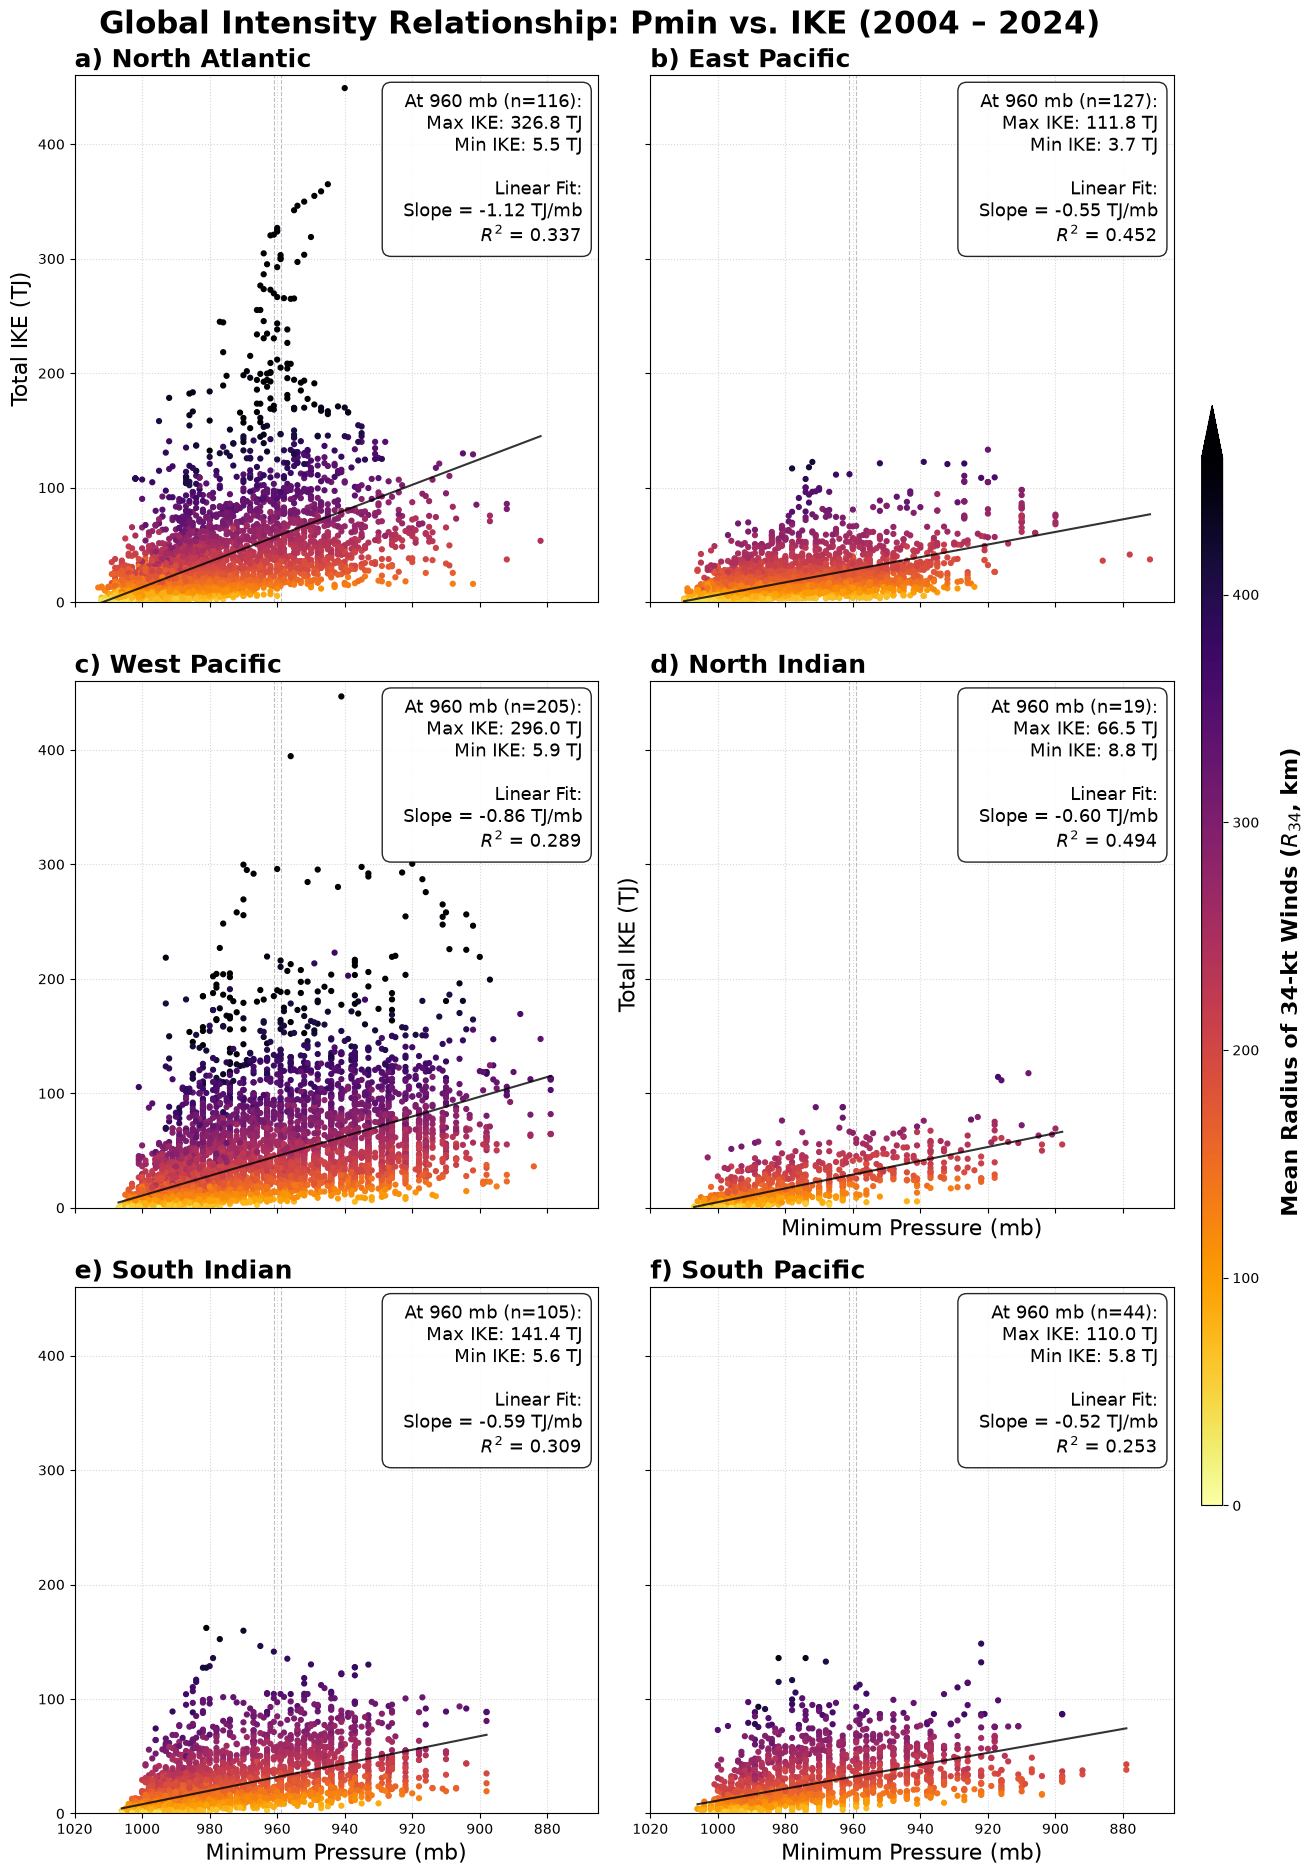

In [6]:
def plot_6panel_ike_intensity(df, metric_key, start_year, end_year, output_dir):
    cfg = INTENSITY_CONFIGS[metric_key]
    x_col, x_label, title_var = cfg["x_col"], cfg["x_label"], cfg["title_var"]
    target, tol, unit_label = cfg["target"], cfg["tol"], cfg["unit_label"]

    basins =[
    "North Atlantic", "East Pacific", "West Pacific",
    "North Indian", "South Indian", "South Pacific"
]
    panel_labels = ["a", "b", "c", "d", "e", "f"]

    fig, axes = plt.subplots(3, 2, figsize=(14, 22), sharex=True, sharey=True)
    axes = axes.flatten()

    scatter = None
    for i, basin in enumerate(basins):
        ax = axes[i]
        b_df = df[df["basin"] == basin].copy()

        if b_df.empty:
            ax.text(0.5, 0.5, "No Data", transform=ax.transAxes, ha="center")
            continue

        scatter = ax.scatter(
            b_df[x_col], b_df["total_ike_tj"],
            c=b_df["r34_km"], cmap="inferno_r",
            alpha=1, s=12, vmin=0, vmax=460, zorder=2,
        )

        reg_df = b_df.dropna(subset=[x_col, "total_ike_tj"])
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            reg_df[x_col], reg_df["total_ike_tj"]
        )

        x_fit = np.linspace(reg_df[x_col].min(), reg_df[x_col].max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color="black", linestyle="-", linewidth=1.5,
                alpha=0.8, zorder=4, label="Linear fit")

        ax.set_title(f"{panel_labels[i]}) {basin}", fontsize=18, weight="bold", loc="left")
        ax.grid(True, linestyle=":", alpha=0.5)

        ax.set_xlim(*cfg["xlim"])
        if cfg["invert_xaxis"]:
            ax.invert_xaxis()
        ax.set_ylim(0, 460)

        if i >= 3:
            ax.set_xlabel(x_label, fontsize=16)
        if i % 3 == 0:
            ax.set_ylabel("Total IKE (TJ)", fontsize=16)

        window = b_df[(b_df[x_col] >= target - tol) & (b_df[x_col] <= target + tol)]

        if not window.empty:
            ike_max = window["total_ike_tj"].max()
            ike_min = window["total_ike_tj"].min()
            n_pts = len(window)
            annotation_text = (
                f"At {target} {unit_label} (n={n_pts}):\n"
                f"  Max IKE: {ike_max:.1f} TJ\n"
                f"  Min IKE: {ike_min:.1f} TJ\n\n"
                f"Linear Fit:\n"
                f"  Slope = {slope:.2f} TJ/{unit_label.rstrip('s')}\n"
                f"  $R^2$ = {r_value**2:.3f}"
            )
        else:
            annotation_text = (
                f"At {target} \u00b1 {tol} {unit_label}:\n  No data\n\n"
                f"Linear fit:\n"
                f"  slope = {slope:.2f} TJ/{unit_label.rstrip('s')}\n"
                f"  $R^2$ = {r_value**2:.3f}\n"
                f"  p = {p_value:.2e}"
            )

        ax.text(0.97, 0.97, annotation_text,
                transform=ax.transAxes,
                fontsize=13, verticalalignment="top", horizontalalignment="right",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                          edgecolor="black", alpha=0.85),
                zorder=5)

        ax.axvline(target - tol, color="gray", linestyle="--", linewidth=0.8, alpha=0.5, zorder=1)
        ax.axvline(target + tol, color="gray", linestyle="--", linewidth=0.8, alpha=0.5, zorder=1)

    if scatter is not None:
        cbar_ax = fig.add_axes([0.93, 0.25, 0.015, 0.5])
        cbar = fig.colorbar(scatter, cax=cbar_ax, extend="max")
        cbar.set_label("Mean Radius of 34-kt Winds ($R_{34}$, km)", fontsize=16, weight="bold", labelpad=15)

    plt.suptitle(f"Global Intensity Relationship: {title_var} vs. IKE ({start_year} \u2013 {end_year})",
                 fontsize=22, weight="bold", y=0.93)

    plt.subplots_adjust(right=0.91, top=0.90, hspace=0.15, wspace=0.1)

    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, cfg["filename"]), dpi=300, bbox_inches="tight")
    plt.show()


plot_6panel_ike_intensity(
    valid_ike_master, INTENSITY_METRIC, config.START_YEAR, config.END_YEAR, config.BASE_OUTPUT_DIR
)
